**[🏠 Course Home](00_START_HERE.ipynb)** | **Sheet 1 of 5: Foundations** | [➡️ Next: Sheet 2 (Quadratic Approx)](02_quadratic_laplace_approximation.ipynb)

---

# Sheet 1: Estimating Population Mean Height — Frequentist vs. Bayesian Grid Approximation

This notebook provides an integrated, step-by-step masterclass on estimating population mean height ($\mu$) and standard deviation ($\sigma$).

Each conceptual and mathematical **Deep Dive** is directly paired with its corresponding **executable code block**, allowing you to inspect intermediate variables, verify the mathematics, and see exactly how theory translates into Base R computation.

---

## Table of Contents
1. **Part 1: The Problem & Observed Data** (Generative Model & Simulation)
2. **Part 2: The Frequentist Paradigm** (Sample Mean, Standard Error, $t$-test Confidence Interval)
3. **Part 3: The Bayesian Pipeline — Interleaved Deep Dives & Code**
   - **Step 0**: Setting Priors & Prior Predictive Simulation
   - **Step 1**: Discretizing Parameter Space into a 2D Grid
   - **Step 2 & Deep Dive 1**: Computing Log-Likelihood & Why Likelihood is the Product of `dnorm()`
   - **Step 3 & Deep Dives 2 & 3**: Computing Log-Prior, Bayes' Rule & The MAP (Maximum A Posteriori) Peak
   - **Step 4 & Deep Dive 4**: Normalizing Probabilities via the Log-Sum-Exp Trick
   - **Step 5 & Deep Dive 5**: Sampling from the 2D Grid & Free Marginalization
   - **Step 6 & Deep Dive 6**: Summarizing the Posterior (Mean, SD, 95% Credible Interval)
   - **Step 7 & Deep Dive 7**: The Posterior Predictive Distribution (Parameters vs. Observables)
4. **Part 4: Visualizing Parameter Uncertainty vs. Outcome Prediction**
5. **Part 5: Prior Sensitivity & Shrinkage Analysis** (Flat vs. Weak vs. Skeptical Priors)
6. **Part 6: Common Traps & FAQs** (The Bernstein-von Mises Theorem & Natural $\sqrt{n}$ Convergence)
7. **Part 7: Hands-On Challenge Exercises**

## Part 1: The Problem & Observed Data

### 1.1 The Generative Model
Suppose we want to know the average height of an adult population. We collect a sample of $n = 50$ adult heights: $y = (y_1, y_2, \dots, y_n)$.

We assume heights follow a Gaussian (Normal) generative process:
$$y_i \sim \text{Normal}(\mu, \sigma^2)$$
where:
- $\mu$ is the **true population mean height** (in cm).
- $\sigma$ is the **true standard deviation** (spread of heights among individuals, in cm).

Sample Size (n): 50
Sample Mean:     172.21 cm
Sample SD:       9.21 cm


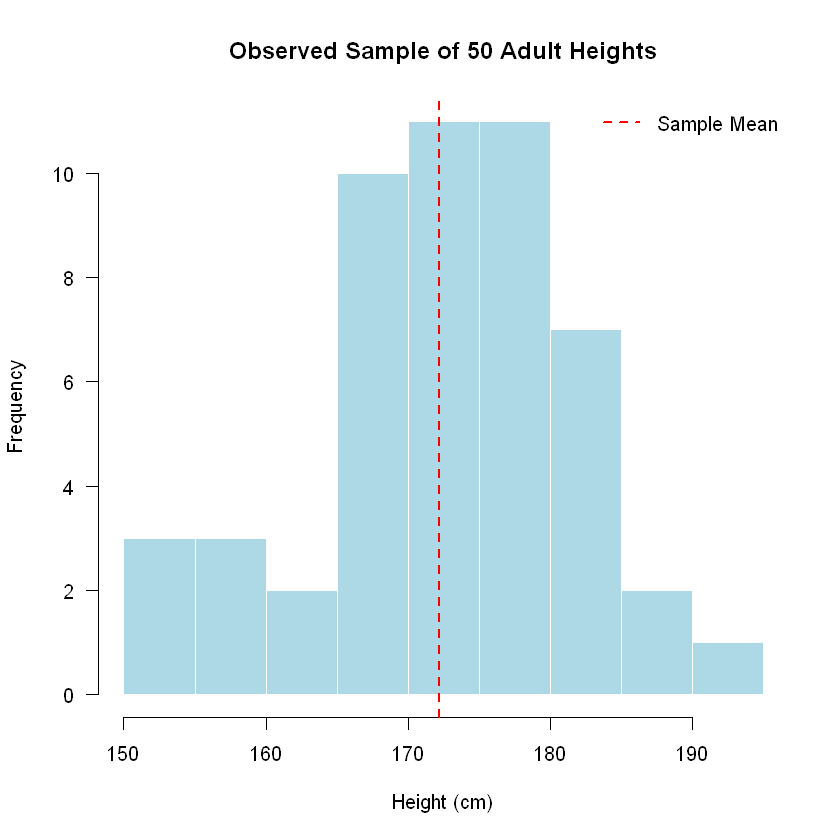

In [27]:
# Set seed for reproducibility (comment out to see random sampling fluctuations!)
set.seed(42)
n <- 50
true_mu <- 172.5
true_sigma <- 8.0

# Simulate sample data
heights <- rnorm(n, mean = true_mu, sd = true_sigma)

cat(sprintf("Sample Size (n): %d\n", n))
cat(sprintf("Sample Mean:     %.2f cm\n", mean(heights)))
cat(sprintf("Sample SD:       %.2f cm\n", sd(heights)))

# Visual Inspection of Sample
hist(heights, breaks = 12, col = "lightblue", border = "white", 
     main = "Observed Sample of 50 Adult Heights", xlab = "Height (cm)", las = 1)
abline(v = mean(heights), col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Sample Mean"), col = "red", lty = 2, lwd = 2, bty = "n")

## Part 2: The Frequentist Paradigm

### 2.1 Philosophy
- The parameter $\mu$ is a **fixed, single, unknown constant**.
- Probability is defined strictly as **long-run relative frequency** under infinite hypothetical repetitions of the sampling experiment.

### 2.2 Point Estimation & Standard Error
- **Point Estimate (Sample Mean)**: $\hat{\mu} = \bar{y} = \frac{1}{n} \sum_{i=1}^n y_i$
- **Standard Error of the Mean**: $\text{SE} = \frac{s}{\sqrt{n}}$, where $s = \sqrt{\frac{1}{n-1}\sum (y_i - \bar{y})^2}$.
- **95% Confidence Interval (CI)**:
  $$\text{CI}_{95\%} = \left[ \bar{y} - t_{n-1, 0.975} \cdot \text{SE}, \; \bar{y} + t_{n-1, 0.975} \cdot \text{SE} \right]$$

> **Crucial Frequentist Interpretation**: A 95% Confidence Interval does **not** mean there is a 95% chance $\mu$ is inside this interval. The true parameter $\mu$ is fixed (it is either in the interval or not, 0 or 1). Instead, it means: *If we repeat this sampling experiment infinitely many times and compute a CI each time, 95% of those calculated intervals will capture $\mu$.*

In [28]:
# Frequentist estimation using t.test
freq_fit  <- t.test(heights)
freq_mean <- freq_fit$estimate
freq_ci   <- freq_fit$conf.int
freq_se   <- sd(heights) / sqrt(n)

cat("=== Frequentist Results ===\n")
cat(sprintf("Point Estimate (Sample Mean): %.2f cm\n", freq_mean))
cat(sprintf("Standard Error (SE):          %.3f cm\n", freq_se))
cat(sprintf("95%% Confidence Interval:       [%.2f, %.2f] cm\n", freq_ci[1], freq_ci[2]))

=== Frequentist Results ===
Point Estimate (Sample Mean): 172.21 cm
Standard Error (SE):          1.303 cm
95% Confidence Interval:       [169.60, 174.83] cm


## Part 3: The Bayesian Pipeline — Interleaved Deep Dives & Code

In Bayesian inference, parameters $\mu$ and $\sigma$ are treated as **random variables** whose probability distributions quantify our state of knowledge/epistemic uncertainty.

---

### Step 0: Setting Priors & Prior Predictive Simulation

Before analyzing our 50 data points, we establish our prior distributions based on domain knowledge of human biology:
- $\mu \sim \text{Normal}(\mu_0 = 170, \sigma_0 = 15)$: We expect adult population averages to hover around 170 cm; 95% of our prior mass spans $[140, 200]$ cm.
- $\sigma \sim \text{Uniform}(0, 30)$: Variation is strictly positive, but population SD rarely exceeds 30 cm.

**Prior Predictive Check**: What kind of human heights does our model expect *before seeing any data*? We simulate $10,000$ individuals purely from the prior.

=== Prior Predictive Check ===
Prior Expected Mean: 169.8 cm
Prior Predictive 95% Interval for Individuals: [123.6, 216.3] cm


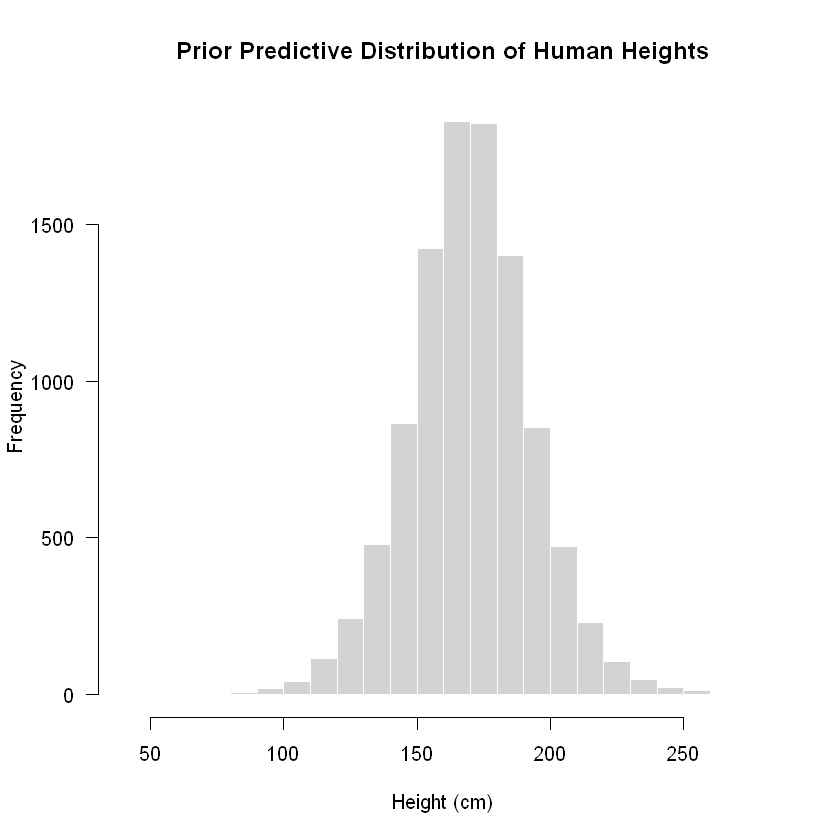

In [29]:
# Step 0: Prior Predictive Simulation
n_sim <- 1e4
prior_mu_sim    <- rnorm(n_sim, mean = 170, sd = 15)
prior_sigma_sim <- runif(n_sim, min = 0, max = 30)
prior_heights   <- rnorm(n_sim, mean = prior_mu_sim, sd = prior_sigma_sim)

cat("=== Prior Predictive Check ===\n")
cat(sprintf("Prior Expected Mean: %.1f cm\n", mean(prior_mu_sim)))
cat(sprintf("Prior Predictive 95%% Interval for Individuals: [%.1f, %.1f] cm\n", 
            quantile(prior_heights, 0.025), quantile(prior_heights, 0.975)))

hist(prior_heights, breaks = 30, col = "lightgray", border = "white", 
     main = "Prior Predictive Distribution of Human Heights", xlab = "Height (cm)", las = 1)

### Step 1: Discretizing Parameter Space into a 2D Grid

How does **Grid Approximation** work?
1. We lay down a 2D coordinate grid of candidate values for $\mu$ and $\sigma$.
2. We choose $300$ candidate values for $\mu \in [160, 185]$ cm and $300$ candidate values for $\sigma \in [2, 20]$ cm.
3. Using R's `expand.grid()`, this creates a matrix of $300 \times 300 = 90,000$ unique $(\mu, \sigma)$ parameter pairs.

At every single point on this grid, we will evaluate how well that specific $(\mu, \sigma)$ pair explains our 50 observed heights.

In [30]:
# Step 1: Define Grid Axes and Construct the 2D Coordinate Grid
mu_grid    <- seq(from = 160, to = 185, length.out = 300)
sigma_grid <- seq(from = 2,   to = 20,  length.out = 300)
grid       <- expand.grid(mu = mu_grid, sigma = sigma_grid)

cat("=== Grid Structure ===\n")
cat(sprintf("Total grid rows (parameter combinations): %d\n", nrow(grid)))
cat("First 5 candidate parameter combinations:\n")
print(head(grid, 5))
cat(sprintf("Range of mu candidates:    [%.2f, %.2f] cm\n", min(grid$mu), max(grid$mu)))
cat(sprintf("Range of sigma candidates: [%.2f, %.2f] cm\n", min(grid$sigma), max(grid$sigma)))


=== Grid Structure ===
Total grid rows (parameter combinations): 90000
First 5 candidate parameter combinations:
        mu sigma
1 160.0000     2
2 160.0836     2
3 160.1672     2
4 160.2508     2
5 160.3344     2
Range of mu candidates:    [160.00, 185.00] cm
Range of sigma candidates: [2.00, 20.00] cm


### Step 2 & Deep Dive 1: Computing the Log-Likelihood

### Deep Dive 1: Why Likelihood is the Product of `dnorm()`

Why does $P(y \mid \mu, \sigma) = \prod_{i=1}^n \text{dnorm}(y_i, \mu, \sigma)$?

1. **Conditional Independence (i.i.d.)**: Given true parameters $(\mu, \sigma)$, knowing one person's height gives zero additional information about another person's height.
2. **Multiplication Rule for Joint Probability**: For independent events, the joint probability is the product of individual probabilities: $P(A \cap B) = P(A) \times P(B)$.
   $$P(y_1, y_2, \dots, y_n \mid \mu, \sigma) = P(y_1 \mid \mu, \sigma) \times P(y_2 \mid \mu, \sigma) \times \dots \times P(y_n \mid \mu, \sigma) = \prod_{i=1}^n P(y_i \mid \mu, \sigma)$$
3. **What `dnorm()` Evaluates**: For each individual measurement $y_i$, `dnorm()` evaluates the Gaussian probability density function:
   $$P(y_i \mid \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - \mu)^2}{2\sigma^2} \right)$$
4. **Log-Sum Transformation in Code**: Multiplying 50 small decimals causes **arithmetic underflow** to `0.0` on a computer. Since $\log(a \cdot b) = \log a + \log b$, the product becomes a sum:
   $$\log P(y \mid \mu, \sigma) = \sum_{i=1}^n \log \text{dnorm}(y_i, \mu, \sigma) \quad \Longrightarrow \quad \text{R code: } \texttt{sum(dnorm(heights, mean=mu, sd=sigma, log=TRUE))}$$

Let us evaluate this log-likelihood across all 90,000 grid points:

In [31]:
# Step 2: Compute Log-Likelihood for every grid point
log_lik <- sapply(1:nrow(grid), function(i) {
  sum(dnorm(heights, mean = grid$mu[i], sd = grid$sigma[i], log = TRUE))
})

cat("=== Log-Likelihood Summary ===\n")
cat(sprintf("Total evaluations: %d\n", length(log_lik)))
cat(sprintf("Max Log-Likelihood: %.2f (Peak compatibility with data)\n", max(log_lik)))
cat(sprintf("Min Log-Likelihood: %.2f (Far out in the tails)\n", min(log_lik)))

# Best fit parameter combination according to likelihood alone (MLE):
best_lik_idx <- which.max(log_lik)
cat(sprintf("Maximum Likelihood Estimate (MLE): mu = %.2f cm, sigma = %.2f cm\n", 
            grid$mu[best_lik_idx], grid$sigma[best_lik_idx]))

=== Log-Likelihood Summary ===
Total evaluations: 90000
Max Log-Likelihood: -181.47 (Peak compatibility with data)
Min Log-Likelihood: -1622.02 (Far out in the tails)
Maximum Likelihood Estimate (MLE): mu = 172.21 cm, sigma = 9.10 cm


### Step 3 & Deep Dives 2 & 3: Computing Log-Prior, Unnormalized Posterior & The MAP Peak

### Deep Dive 2: Why Posterior $\propto$ Likelihood $\times$ Prior

1. **Derivation from Conditional Probability**:
   $$P(A \mid B) = \frac{P(A \cap B)}{P(B)} \quad \text{and} \quad P(B \mid A) = \frac{P(A \cap B)}{P(A)} \implies P(A \cap B) = P(B \mid A)P(A)$$
   $$P(A \mid B) = \frac{P(B \mid A)P(A)}{P(B)}$$
   Letting $A = (\mu, \sigma)$ (parameters) and $B = y$ (data):
   $$P(\mu, \sigma \mid y) = \frac{P(y \mid \mu, \sigma) P(\mu, \sigma)}{P(y)} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}$$

2. **Why the Denominator $P(y)$ is Just a Constant Normalizer**:
   $P(y) = \iint P(y \mid \mu, \sigma) P(\mu, \sigma) \, d\mu d\sigma = \sum_{\text{grid rows}} \text{Likelihood} \times \text{Prior}$.
   $P(y)$ evaluates to a single fixed number (a constant) with no free parameters. Therefore, the shape and relative probabilities of the posterior are strictly governed by:
   $$\text{Posterior} \propto \text{Likelihood} \times \text{Prior}$$

### Deep Dive 3: How & Why We Compute the Log-Prior

1. **Independence of Priors**: Assuming $\mu$ and $\sigma$ are independent prior to seeing data:
   $$P(\mu, \sigma) = P(\mu) \times P(\sigma) \implies \log P(\mu, \sigma) = \log P(\mu) + \log P(\sigma)$$
2. **Scale Compatibility**: The log-likelihood produces values around $-174$. To add them via $\log(\text{Posterior}) = \log(\text{Likelihood}) + \log(\text{Prior})$, the prior must be computed in log units.

### Deep Dive 3.5: What is the MAP (Maximum A Posteriori) Peak?

The parameter combination that yields the highest summit on the posterior surface is the **MAP estimate** $\hat{\theta}_{\text{MAP}} = (\hat{\mu}_{\text{MAP}}, \hat{\sigma}_{\text{MAP}})$:
$$\hat{\theta}_{\text{MAP}} = \arg\max_\theta \, P(\theta \mid y) = \arg\max_\theta \Big[ \log \mathcal{L}(y \mid \theta) + \log P(\theta) \Big]$$

| Estimator | Formula | Considers Prior? | Intuition / Decision Theory |
| :--- | :--- | :---: | :--- |
| **Frequentist MLE** (Step 2) | $\arg\max_\theta \log \mathcal{L}(y \mid \theta)$ | ❌ No | Parameter value most compatible with observed data alone |
| **Bayesian MAP** (Step 3) | $\arg\max_\theta [\log \mathcal{L} + \log P(\theta)]$ | ✅ Yes | Highest posterior density peak (mode). Optimal under 0-1 loss |
| **Posterior Mean** (Step 6) | $\mathbb{E}[\theta \mid y] = \int \theta P(\theta \mid y) d\theta$ | ✅ Yes | Center of probability mass. Optimal under quadratic ($L_2$) loss |

- **Shrinkage & Regularization**: If the prior is flat/uniform, the MAP is identical to the MLE. When an informative prior is added, the MAP peak is pulled ("shrunk") from the MLE toward the prior mean.
- **Crucial Role in Step 4**: In the **Log-Sum-Exp trick**, subtracting this peak value ($M = \max(\log P)$) prevents numerical underflow to `0.0`.
- **Crucial Role in Sheet 2**: In **Quadratic / Laplace Approximation**, instead of computing 90,000 grid points, an optimizer sprints directly to this **MAP peak** in 0.001s, then inverts the Hessian matrix (curvature) to form an analytical Gaussian approximation.

Let us compute the log-priors, combine them with log-likelihood, and identify the MAP peak:


In [32]:
# Step 3: Compute Log-Prior and Unnormalized Log-Posterior
log_prior_mu    <- dnorm(grid$mu, mean = 170, sd = 15, log = TRUE)
log_prior_sigma <- dunif(grid$sigma, min = 0, max = 30, log = TRUE)
log_prior       <- log_prior_mu + log_prior_sigma

# Combine in log-space: log(Posterior) = log(Likelihood) + log(Prior)
log_post <- log_lik + log_prior

# Identify the MAP (Maximum A Posteriori) Peak on the grid
map_idx   <- which.max(log_post)
map_mu    <- grid$mu[map_idx]
map_sigma <- grid$sigma[map_idx]

cat("=== Prior & Unnormalized Posterior Summary ===\n")
cat(sprintf("Log-Prior range:     [%.2f, %.2f]\n", min(log_prior), max(log_prior)))
cat(sprintf("Log-Posterior range: [%.2f, %.2f]\n", min(log_post), max(log_post)))
cat(sprintf("Max Log-Posterior:   %.2f (The MAP peak)\n", max(log_post)))
cat(sprintf("MAP Estimate (Mode): mu = %.2f cm, sigma = %.2f cm\n", map_mu, map_sigma))


=== Prior & Unnormalized Posterior Summary ===
Log-Prior range:     [-7.53, -7.03]
Log-Posterior range: [-1629.55, -188.51]
Max Log-Posterior:   -188.51 (The MAP peak)
MAP Estimate (Mode): mu = 172.21 cm, sigma = 9.10 cm


### Step 4 & Deep Dive 4: Normalizing via the Log-Sum-Exp Trick

### Deep Dive 4: The Log-Sum-Exp Trick & Numerical Underflow

To normalize unnormalized log-posterior values $\log P_i$ into probabilities that sum to 1:
$$P_i = \frac{\exp(\log P_i)}{\sum_j \exp(\log P_j)}$$
- If $\log P_i \approx -174$, standard $\exp(-174)$ produces `0.0` (IEEE-754 underflow), yielding `0 / 0 = NaN`.
- **The Exact Mathematical Fix** (Log-Sum-Exp Trick): Factor out the maximum value $M = \max(\log P)$:
  $$P_i = \frac{\exp(\log P_i - M) \cdot \exp(M)}{\sum_j \exp(\log P_j - M) \cdot \exp(M)} = \frac{\exp(\log P_i - M)}{\sum_j \exp(\log P_j - M)}$$
- This shifts the highest log-probability to $\exp(0) = 1.0$, guaranteeing numerical stability with **zero mathematical distortion**.

Let us execute the Log-Sum-Exp trick and verify that probabilities sum to exactly 1.0:

In [33]:
# Step 4: Normalize Log-Posterior into Probabilities via Log-Sum-Exp Trick
post_prob <- exp(log_post - max(log_post))
post_prob <- post_prob / sum(post_prob)

cat("=== Normalized Posterior Probabilities ===\n")
cat(sprintf("Sum of all grid probabilities: %.10f (Must equal 1.0!)\n", sum(post_prob)))
cat(sprintf("Max probability assigned to single cell: %.6f\n", max(post_prob)))
cat(sprintf("Number of grid points with >99.9%% of total probability mass: %d / %d\n", 
            sum(cumsum(sort(post_prob, decreasing = TRUE)) <= 0.999), nrow(grid)))

=== Normalized Posterior Probabilities ===
Sum of all grid probabilities: 1.0000000000 (Must equal 1.0!)
Max probability assigned to single cell: 0.000654
Number of grid points with >99.9% of total probability mass: 12356 / 90000


### Step 5 & Deep Dive 5: Drawing Samples from the 2D Grid

### Deep Dive 5: Why We Sample from the Posterior Grid

Instead of doing calculus or weighted matrix sums on the 90,000 grid points, we draw 10,000 weighted samples (`sample(..., prob = post_prob)`):
1. **Automatic Marginalization**: To isolate parameter $\mu$ and ignore $\sigma$, you simply look at `posterior_mu` without doing any integrals.
2. **Trivial Transformations**: To find the distribution of any non-linear function (e.g., Coefficient of Variation $\text{CV} = \sigma / \mu$), just compute `posterior_sigma / posterior_mu` directly on the sample vectors.
3. **Universal Paradigm**: Prepares you for MCMC (Stan / `brms`), which always operates on posterior sample vectors.

Let us draw 10,000 parameter pairs according to `post_prob`:

In [34]:
# Step 5: Draw 10,000 weighted samples from the grid
set.seed(42)
samples_idx     <- sample(1:nrow(grid), size = 1e4, replace = TRUE, prob = post_prob)
posterior_mu    <- grid$mu[samples_idx]
posterior_sigma <- grid$sigma[samples_idx]

cat("=== Posterior Samples Drawn ===\n")
cat(sprintf("Total samples drawn: %d\n", length(posterior_mu)))
cat("First 5 sampled (mu, sigma) pairs:\n")
print(head(data.frame(mu = posterior_mu, sigma = posterior_sigma), 5))

=== Posterior Samples Drawn ===
Total samples drawn: 10000
First 5 sampled (mu, sigma) pairs:
        mu     sigma
1 173.5452  9.043478
2 170.3679  9.525084
3 172.4582  8.682274
4 172.6254  8.983278
5 171.9565 10.608696


### Step 6 & Deep Dive 6: Summarizing the Posterior Distribution

### Deep Dive 6: Summarizing the Posterior Distribution

- **Posterior Mode / MAP** (`grid[which.max(log_post), ]`): The single most probable parameter combination (the MAP peak). Optimal point estimate under **0-1 (all-or-nothing) loss**.
- **Posterior Mean** (`mean(posterior_mu)`): Center of mass / expectation. Optimal point estimate under **quadratic ($L_2$) loss**.
- **Posterior Median** (`median(posterior_mu)`): 50th percentile. Optimal point estimate under **absolute ($L_1$) loss**.
- **Posterior Standard Deviation** (`sd(posterior_mu)`): Bayesian measure of parameter uncertainty.
- **95% Credible Interval** (`quantile(posterior_mu, c(0.025, 0.975))`): Direct probability statement:
  > *"Given our prior and the observed data, there is a 95% probability that the population mean height $\mu$ lies between these bounds."*

Let us summarize our posterior distributions for $\mu$ and $\sigma$:


In [35]:
# Step 6: Compute Summary Statistics
bayes_mean_mu <- mean(posterior_mu)
bayes_sd_mu   <- sd(posterior_mu)
bayes_ci_mu   <- quantile(posterior_mu, probs = c(0.025, 0.975))

bayes_mean_sigma <- mean(posterior_sigma)
bayes_sd_sigma   <- sd(posterior_sigma)
bayes_ci_sigma   <- quantile(posterior_sigma, probs = c(0.025, 0.975))

cat("=== Bayesian Posterior Summary (Population Parameters) ===\n")
cat(sprintf("Mean Height (mu):       %.2f cm (SD: %.3f cm) | 95%% CI: [%.2f, %.2f] cm\n",
            bayes_mean_mu, bayes_sd_mu, bayes_ci_mu[1], bayes_ci_mu[2]))
cat(sprintf("Height Spread (sigma):  %.2f cm (SD: %.3f cm) | 95%% CI: [%.2f, %.2f] cm\n",
            bayes_mean_sigma, bayes_sd_sigma, bayes_ci_sigma[1], bayes_ci_sigma[2]))
cat(sprintf("MAP Peak Mode (Grid):   mu = %.2f cm, sigma = %.2f cm\n",
            map_mu, map_sigma))


=== Bayesian Posterior Summary (Population Parameters) ===
Mean Height (mu):       172.20 cm (SD: 1.345 cm) | 95% CI: [169.53, 174.80] cm
Height Spread (sigma):  9.48 cm (SD: 0.992 cm) | 95% CI: [7.78, 11.63] cm
MAP Peak Mode (Grid):   mu = 172.21 cm, sigma = 9.10 cm


### Step 7 & Deep Dive 7: The Posterior Predictive Distribution

### Deep Dive 7: The Posterior Predictive Distribution (Parameters vs. Observables)

The **Posterior Predictive Distribution (PPD)** answers: *"Now that we have learned from our sample of 50 people, what should we expect the **next individual person's height** to be?"*

#### 1. The Two Layers of Uncertainty:
Total predictive uncertainty is the sum of two distinct sources:
$$\text{Total Uncertainty} = \underbrace{\text{Parameter Uncertainty (Epistemic)}}_{\text{Shrinks to } 0 \text{ as } n \to \infty} + \underbrace{\text{Natural Biological Variation (Aleatoric)}}_{\text{Never shrinks to } 0}$$

- **Parameter Uncertainty** ($P(\mu, \sigma \mid y)$): We only measured 50 people, so the true population mean $\mu$ is uncertain (spread $\approx \pm 1.1\text{ cm}$).
- **Individual Variation** ($y_{\text{new}} \sim \text{Normal}(\mu, \sigma)$): Even if we knew $\mu$ and $\sigma$ with 100% precision, humans are not identical clones—individuals vary widely (spread $\approx \pm 8.0\text{ cm}$).

#### 2. The Mathematical Formulation:
We integrate the likelihood of a new individual across all plausible $(\mu, \sigma)$ parameter pairs, weighted by their posterior probabilities:
$$P(y_{\text{new}} \mid y) = \iint \underbrace{\text{Normal}(y_{\text{new}} \mid \mu, \sigma)}_{\text{Likelihood of new person}} \times \underbrace{P(\mu, \sigma \mid y)}_{\text{Posterior weight of parameters}} \, d\mu \, d\sigma$$

#### 3. How It Is Simulated in 1 Line of R Code:
```r
# Each simulated person draws from a slightly different (mu, sigma) pair from the posterior:
post_pred_heights <- rnorm(n = 1e4, mean = posterior_mu, sd = posterior_sigma)
```

Let us simulate 10,000 future individuals and inspect the resulting prediction interval:

In [36]:
# Step 7: Simulate Posterior Predictive Heights
set.seed(42)
post_pred_heights <- rnorm(1e4, mean = posterior_mu, sd = posterior_sigma)
pred_mean         <- mean(post_pred_heights)
pred_ci           <- quantile(post_pred_heights, probs = c(0.025, 0.975))

cat("=== Parameter Uncertainty vs. Individual Prediction Interval ===\n")
cat(sprintf("95%% Credible Interval for Population Mean mu:  [%.2f, %.2f] cm (Width: %.2f cm)\n", 
            bayes_ci_mu[1], bayes_ci_mu[2], bayes_ci_mu[2] - bayes_ci_mu[1]))
cat(sprintf("95%% Prediction Interval for Individual Person: [%.2f, %.2f] cm (Width: %.2f cm)\n", 
            pred_ci[1], pred_ci[2], pred_ci[2] - pred_ci[1]))

=== Parameter Uncertainty vs. Individual Prediction Interval ===
95% Credible Interval for Population Mean mu:  [169.53, 174.80] cm (Width: 5.27 cm)
95% Prediction Interval for Individual Person: [153.09, 191.03] cm (Width: 37.94 cm)


## Part 4: Visualizing Parameter Uncertainty vs. Outcome Prediction

Let us visualize:
1. **Parameter Estimation**: Frequentist Point Estimate & 95% CI vs. Bayesian Posterior Density & 95% Credible Interval.
2. **Outcome Prediction**: Uncertainty in the Mean ($\mu$) vs. Uncertainty in a New Individual ($y_{\text{new}}$).

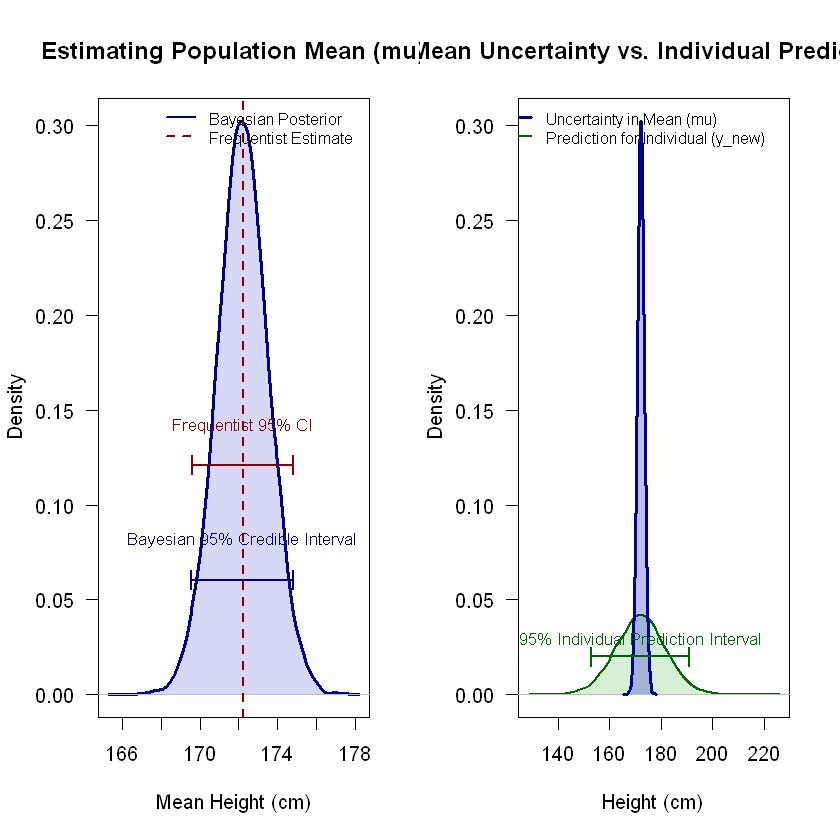

In [37]:
par(mfrow = c(1, 2))

# Plot 1: Estimating Population Mean (mu)
dens_mu <- density(posterior_mu)
plot(dens_mu, main = "Estimating Population Mean (mu)", 
     xlab = "Mean Height (cm)", col = "darkblue", lwd = 3, las = 1)
polygon(dens_mu, col = rgb(0, 0, 0.8, 0.15), border = NA)

# Frequentist Mean & CI
abline(v = freq_mean, col = "darkred", lwd = 2, lty = 2)
arrows(freq_ci[1], max(dens_mu$y)*0.4, freq_ci[2], max(dens_mu$y)*0.4, 
       angle = 90, code = 3, length = 0.08, col = "darkred", lwd = 2)
text(freq_mean, max(dens_mu$y)*0.47, "Frequentist 95% CI", col = "darkred", cex = 0.85)

# Bayesian Credible Interval
arrows(bayes_ci_mu[1], max(dens_mu$y)*0.2, bayes_ci_mu[2], max(dens_mu$y)*0.2, 
       angle = 90, code = 3, length = 0.08, col = "darkblue", lwd = 2)
text(bayes_mean_mu, max(dens_mu$y)*0.27, "Bayesian 95% Credible Interval", col = "darkblue", cex = 0.85)

legend("topright", legend = c("Bayesian Posterior", "Frequentist Estimate"),
       col = c("darkblue", "darkred"), lty = c(1, 2), lwd = 2, bty = "n", cex = 0.8)

# Plot 2: Mean Uncertainty vs. Individual Prediction
dens_pred <- density(post_pred_heights)
plot(dens_pred, main = "Mean Uncertainty vs. Individual Prediction", 
     xlab = "Height (cm)", col = "darkgreen", lwd = 2, las = 1, ylim = c(0, max(dens_mu$y)))
polygon(dens_pred, col = rgb(0, 0.6, 0, 0.15), border = NA)

lines(dens_mu, col = "darkblue", lwd = 3)
polygon(dens_mu, col = rgb(0, 0, 0.8, 0.25), border = NA)

arrows(pred_ci[1], 0.02, pred_ci[2], 0.02, angle = 90, code = 3, length = 0.08, col = "darkgreen", lwd = 2)
text(mean(post_pred_heights), 0.03, "95% Individual Prediction Interval", col = "darkgreen", cex = 0.85)

legend("topright", legend = c("Uncertainty in Mean (mu)", "Prediction for Individual (y_new)"),
       col = c("darkblue", "darkgreen"), lwd = c(3, 2), bty = "n", cex = 0.8)

par(mfrow = c(1, 1))

## Part 5: Prior Sensitivity & Shrinkage Analysis

Let us compare three distinct priors on the exact same 50 height observations:
1. **Flat Prior**: $\mu \sim \text{Normal}(170, 1000)$ (Completely non-informative)
2. **Weakly Informative Prior**: $\mu \sim \text{Normal}(170, 15)$ (Our standard model)
3. **Skeptical / Stubborn Prior**: $\mu \sim \text{Normal}(140, 2)$ (Strong prior centered far from data)

Flat Prior Posterior Mean:      172.21 cm
Weak Prior Posterior Mean:      172.20 cm
Skeptical Prior Posterior Mean: 160.35 cm (Shrunk towards 140 cm!)


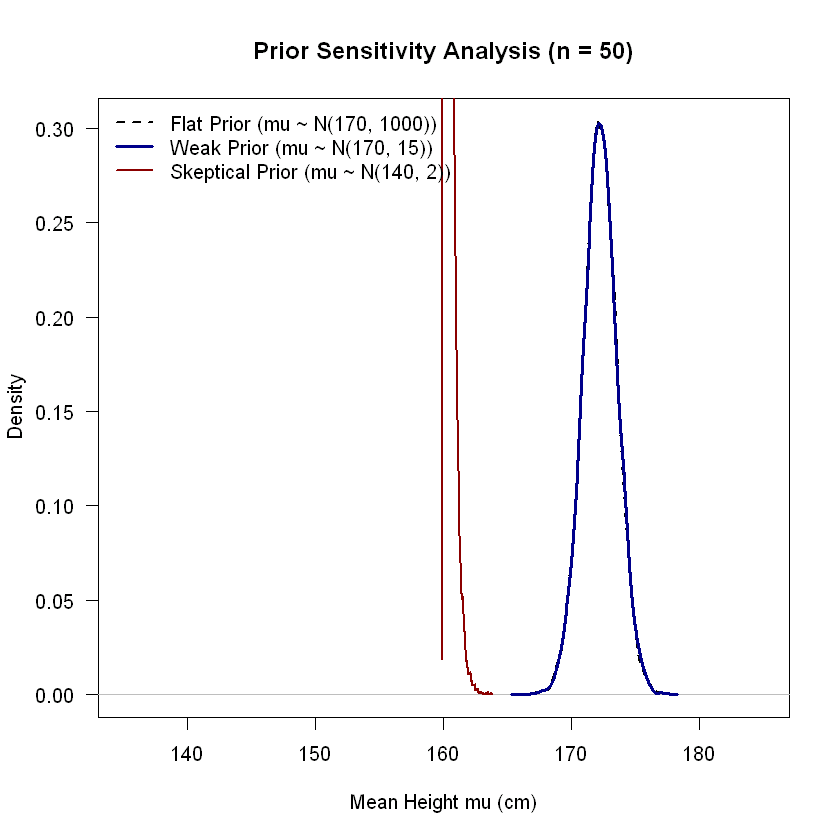

In [38]:
# Compute posterior under Flat Prior
lp_flat <- log_lik + dnorm(grid$mu, 170, 1000, log = TRUE) + dunif(grid$sigma, 0, 30, log = TRUE)
p_flat  <- exp(lp_flat - max(lp_flat)); p_flat <- p_flat / sum(p_flat)
mu_flat <- grid$mu[sample(1:nrow(grid), 1e4, TRUE, p_flat)]

# Compute posterior under Skeptical Prior (mu ~ Normal(140, 2))
lp_skep <- log_lik + dnorm(grid$mu, 140, 2, log = TRUE) + dunif(grid$sigma, 0, 30, log = TRUE)
p_skep  <- exp(lp_skep - max(lp_skep)); p_skep <- p_skep / sum(p_skep)
mu_skep <- grid$mu[sample(1:nrow(grid), 1e4, TRUE, p_skep)]

# Plot Sensitivity Comparison
plot(density(mu_flat), col = "black", lty = 2, lwd = 2, las = 1,
     main = "Prior Sensitivity Analysis (n = 50)", xlab = "Mean Height mu (cm)", xlim = c(135, 185))
lines(density(posterior_mu), col = "darkblue", lwd = 3)
lines(density(mu_skep), col = "darkred", lwd = 2)

legend("topleft", legend = c("Flat Prior (mu ~ N(170, 1000))", 
                             "Weak Prior (mu ~ N(170, 15))", 
                             "Skeptical Prior (mu ~ N(140, 2))"),
       col = c("black", "darkblue", "darkred"), lty = c(2, 1, 1), lwd = c(2, 3, 2), bty = "n")

cat(sprintf("Flat Prior Posterior Mean:      %.2f cm\n", mean(mu_flat)))
cat(sprintf("Weak Prior Posterior Mean:      %.2f cm\n", mean(posterior_mu)))
cat(sprintf("Skeptical Prior Posterior Mean: %.2f cm (Shrunk towards 140 cm!)\n", mean(mu_skep)))

## Part 6: Common Traps & FAQs

### Q1: Why are the Frequentist CI and Bayesian Credible Interval nearly identical here?
- **The Bernstein-von Mises Theorem**: Under weakly informative priors and moderate sample sizes ($n=50$), the Likelihood dominates the prior. When likelihood is Gaussian, the Bayesian posterior and Frequentist sampling distribution are asymptotically identical.
- **The Difference is in the Meaning**: Frequentist CI = coverage rate over infinite repeated experiments. Bayesian CI = direct epistemic probability of $\mu$ given this dataset.

### Q2: Why do Frequentists divide by $\sqrt{n}$, but Bayesians don't?
- In Frequentist formulas, $\text{SE} = s / \sqrt{n}$ is derived analytically.
- In Bayesian inference, we multiply $n$ likelihood terms together. The sum of $n$ squared error terms $(y_i - \mu)^2$ inside the exponential naturally concentrates the posterior variance by a factor of $\frac{1}{n}$, giving standard deviation $\frac{\sigma}{\sqrt{n}}$ **automatically without anyone writing $\sqrt{n}$ in the code!**

## Part 7: Hands-On Challenge Exercises

### Exercise 1: Finding Probability of Extreme Height
Using our posterior predictive sample vector `post_pred_heights`, calculate the probability that a randomly chosen person in this population is taller than **$185\text{ cm}$** ($6'1''$).

```r
# YOUR CODE HERE:
# prob_tall <- mean(post_pred_heights > 185)
```

### Exercise 2: Sample Size Overwhelming a Stubborn Prior
If we had $n = 500$ people instead of $n = 50$, what would happen to the Skeptical Prior estimate? *(Hint: Data likelihood multiplies 500 times, completely overwhelming even a stubborn prior).* 

---

**[🏠 Course Home](00_START_HERE.ipynb)** | [➡️ Next: Sheet 2 (Quadratic Approximation)](02_quadratic_laplace_approximation.ipynb)